In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Tetuan City power consumption.csv")

In [56]:
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [57]:
features = ['Temperature', 'Humidity', 'Wind Speed', 
            'general diffuse flows', 'diffuse flows']

target = ['Zone 1 Power Consumption']

In [106]:
X = np.column_stack([np.ones(len(df)), df[features]])
y = df[target].values

In [107]:
X_train, y_train = X[:1008], y[:1008]
X_test, y_test = X[1008:2016], y[1008:2016]

Initial OLS (G1)

In [108]:
V = np.linalg.inv(X_train.T @ X_train)        # (X'X)^{-1}
beta_hat = V @ X_train.T @ y_train              # OLS estimate

In [109]:
beta_hat

array([[ 1.96636077e+04],
       [ 1.48061391e+03],
       [-6.33735285e+01],
       [ 1.20267864e+03],
       [-1.02262782e+01],
       [-2.03423688e+01]])

In [110]:
beta_hat[1][0]

np.float64(1480.6139146660544)

We focus on the coefficient on temperature throughout this

In [111]:
temp_coefs = []                     # place to store temp coefficients
#temp_coefs.append(beta_hat[1][0])      # beta_0 is the intercept, beta_1 is for temperature

for i in range(len(X_test)):        # iterate thru week 2
    x_new = X_test[i]
    y_new = y_test[i]


# (G2)
    Vx = V @ x_new                  # V x
    denom = 1 + x_new @ Vx          # 1 + x.T (V x)
    V = V - np.outer(Vx, Vx) / denom

# (G3)
    gamma = V @ x_new
    e_hat = y_new - x_new @ beta_hat

# (G4)
    beta_hat = beta_hat + gamma * e_hat

    temp_coefs.append(beta_hat[1][0])


/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_39209/2935799840.py:16: RuntimeWarning: overflow encountered in matmul
  e_hat = y_new - x_new @ beta_hat
/var/folders/1r/_gd8nm2931d2rl2rndmd2_0m0000gn/T/ipykernel_39209/2935799840.py:19: RuntimeWarning: invalid value encountered in add
  beta_hat = beta_hat + gamma * e_hat


In [112]:
df2 = df[1008:2016]

In [113]:
len(df2)

1008

In [114]:
len(temp_coefs)

1008

In [116]:
df2['beta_temp'] = temp_coefs

In [119]:
df2.sample(20)

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,beta_temp
1063,1/8/2017 9:10,13.57,65.68,0.096,66.060,39.610,23580.75949,13714.28571,12607.22892,1.452783e+03
1797,1/13/2017 11:30,15.79,80.20,0.074,184.800,184.900,33952.40506,22588.44985,14041.44578,1.169413e+287
1231,1/9/2017 13:10,16.57,62.62,0.075,441.500,172.400,34535.69620,21060.18237,16724.81928,-1.676460e+50
1517,1/11/2017 12:50,18.14,51.95,0.082,375.800,117.600,33885.56962,20571.42857,17071.80723,2.525705e+193
1922,1/14/2017 8:20,12.53,76.00,0.087,1.588,1.621,24334.17722,14213.98176,11496.86747,NaN
1776,1/13/2017 8:00,12.82,83.70,0.075,0.070,0.148,24540.75949,15217.02128,10768.19277,1.380556e+274
1835,1/13/2017 17:50,15.82,74.80,0.071,24.780,25.170,42094.17722,25823.70821,23965.30120,inf
1618,1/12/2017 5:40,10.57,68.23,0.076,0.051,0.145,22936.70886,14400.00000,14851.08434,4.565632e+184
1355,1/10/2017 9:50,13.22,77.30,0.079,191.100,54.900,30227.84810,18780.54711,14053.01205,-1.103443e+119
1243,1/9/2017 15:10,16.34,66.79,0.075,325.900,249.900,32324.05063,21005.47112,16597.59036,-2.666020e+61


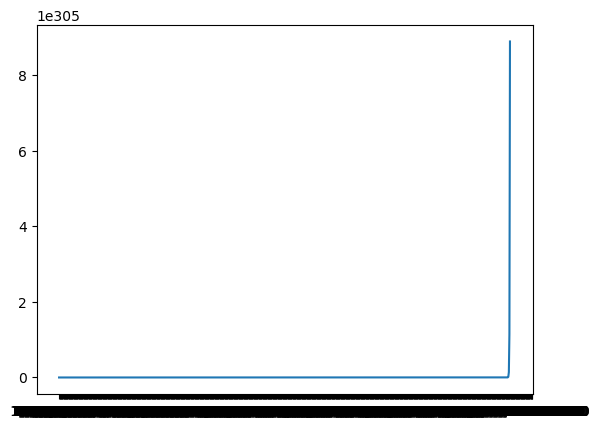

In [117]:
plt.plot(df2['DateTime'], df2['beta_temp'])
plt.show()

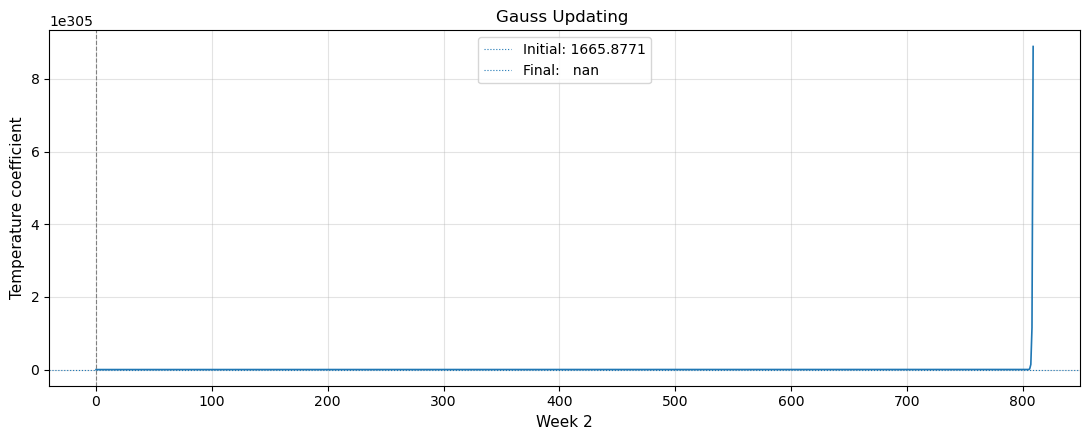

In [122]:
fig, ax = plt.subplots(figsize=(11, 4.5))
 
steps = np.arange(len(temp_coefs))
ax.plot(steps, temp_coefs, lw=1.2,)
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.axhline(temp_coefs[0], lw=0.8, ls=":", label=f"Initial: {temp_coefs[0]:.4f}")
ax.axhline(temp_coefs[-1], lw=0.8, ls=":", label=f"Final:   {temp_coefs[-1]:.4f}")
 
ax.set_xlabel("Week 2", fontsize=11)
ax.set_ylabel("Temperature coefficient", fontsize=11)
ax.set_title("Gauss Updating ", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
fig.tight_layout()
plt.show()